# Bernstein-Vazirani Algorithm
## Finding a Hidden Binary String in One Query

This notebook demonstrates the Bernstein-Vazirani quantum algorithm, which can find an n-bit secret string with just ONE query (compared to n queries classically).

## Setup: Import Required Libraries

In [119]:
# Install packages (uncomment if needed)
%pip install qiskit qiskit-aer matplotlib pylatexenc numpy
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [120]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("All packages imported successfully!")
print(f"Qiskit version: {__import__('qiskit').__version__}")

All packages imported successfully!
Qiskit version: 2.2.1


## The Algorithm Implementation

In [121]:
def bernstein_vazirani_local(secret_string):
    """
    Implement Bernstein-Vazirani algorithm for local simulator
    
    Args:
        secret_string: Binary string to find (e.g., '011', '1101')
    
    Returns:
        Measurement results showing the secret string
    """
    n = len(secret_string)  # number of qubits for the secret
    
    # Create circuit with n qubits + 1 auxiliary qubit
    # and n classical bits for measurement
    bv_circuit = QuantumCircuit(n + 1, n)
    
    # Step 1: Put auxiliary qubit in state |->
    bv_circuit.h(n)  # Apply Hadamard
    bv_circuit.z(n)  # Apply Z gate (makes it |->)
    
    # Step 2: Apply Hadamard gates to all input qubits (create superposition)
    for i in range(n):
        bv_circuit.h(i)
    
    bv_circuit.barrier()
    
    # Step 3: Apply the oracle (encodes the secret string)
    # Reverse the string to match Qiskit's qubit ordering (right to left)
    s = secret_string[::-1]
    
    for q in range(n):
        if s[q] == '1':
            bv_circuit.cx(q, n)  # Controlled-X gate (encodes a '1')
    
    bv_circuit.barrier()
    
    # Step 4: Apply Hadamard gates again (create interference)
    for i in range(n):
        bv_circuit.h(i)
    
    # Step 5: Measure the input qubits
    for i in range(n):
        bv_circuit.measure(i, i)
    
    return bv_circuit


## Example 1: 3-bit Secret String "011"

Example 1: Secret string = '011'

Circuit diagram:


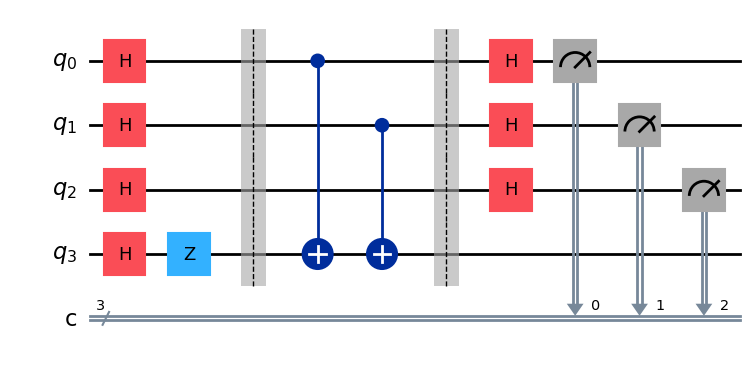

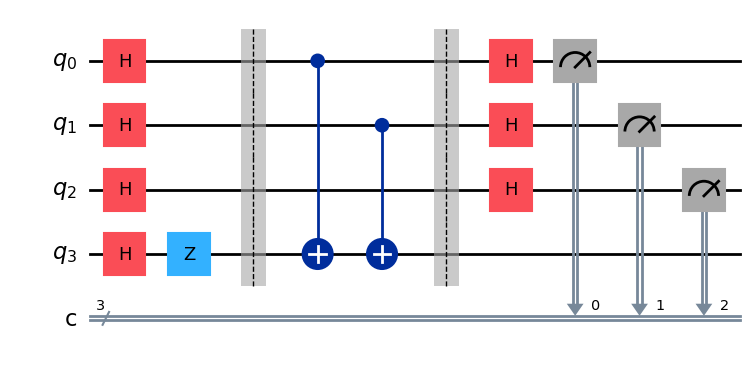

In [122]:
print("=" * 50)
print("Example 1: Secret string = '011'")
print("=" * 50)

secret = '011'
circuit = bernstein_vazirani_local(secret)

# Display the circuit
print("\nCircuit diagram:")
display(circuit.draw('mpl'))

Measurement results:
{'011': 1}

Secret string found: 011


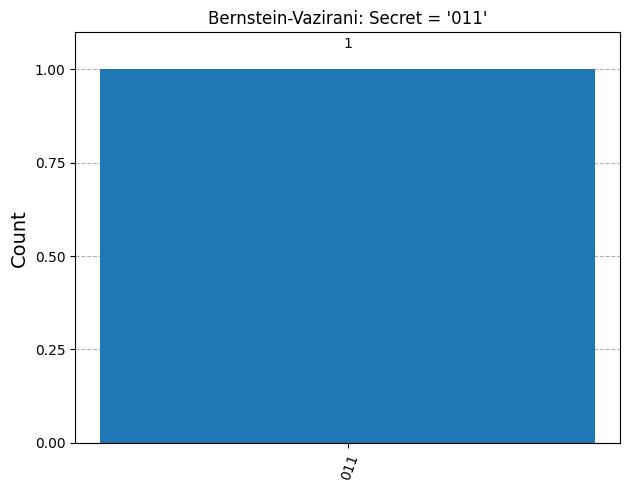

In [123]:
# Run on simulator
simulator = AerSimulator()
job = simulator.run(circuit, shots=1)
result = job.result()
counts = result.get_counts()

# Display results
print(f"Measurement results:")
print(counts)
print(f"\nSecret string found: {max(counts, key=counts.get)}")

# Plot histogram
plot_histogram(counts)
plt.title(f"Bernstein-Vazirani: Secret = '{secret}'")
plt.show()

## Example 2: 4-bit Secret String "1011"

Example 2: Secret string = '1011'


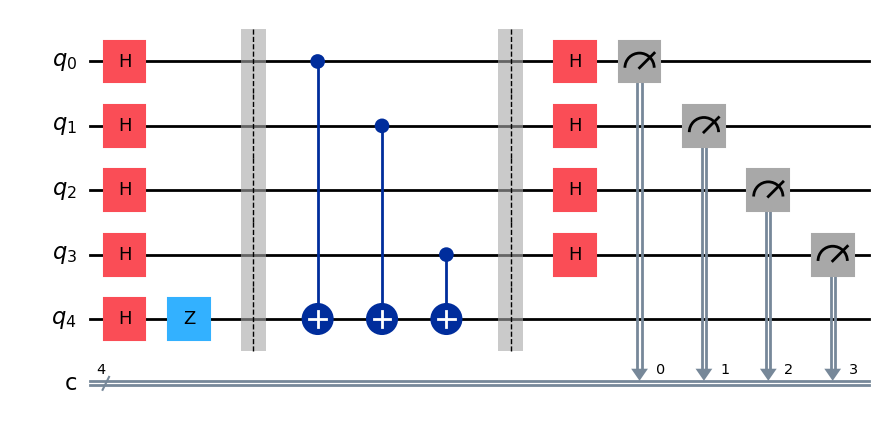

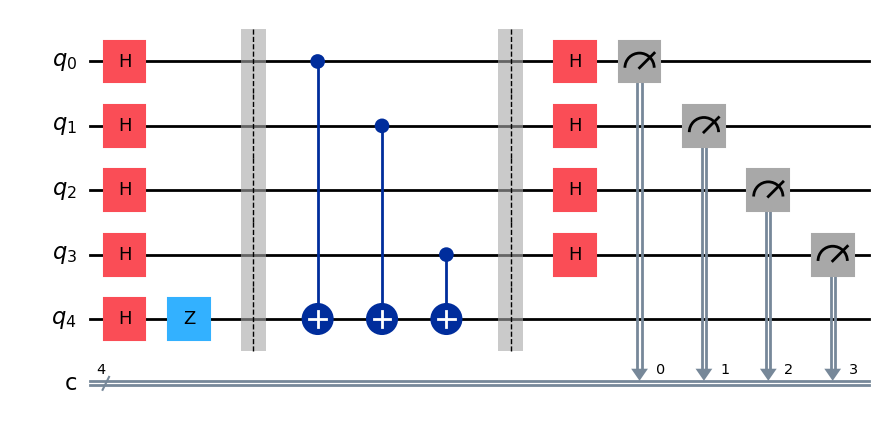

In [124]:
print("=" * 50)
print("Example 2: Secret string = '1011'")
print("=" * 50)

secret = '1011'
circuit = bernstein_vazirani_local(secret)

# Display circuit
display(circuit.draw('mpl'))

Measurement results:
{'1011': 1}

Secret string found: 1011


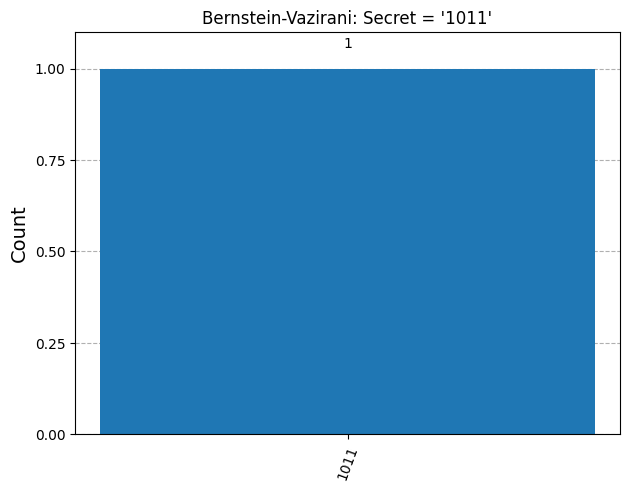

In [125]:
# Run on simulator
job = simulator.run(circuit, shots=1)
result = job.result()
counts = result.get_counts()

print(f"Measurement results:")
print(counts)
print(f"\nSecret string found: {max(counts, key=counts.get)}")

plot_histogram(counts)
plt.title(f"Bernstein-Vazirani: Secret = '{secret}'")
plt.show()

## Example 3: 8-bit Secret String "11101101"

Example 3: Secret string = '11101101'


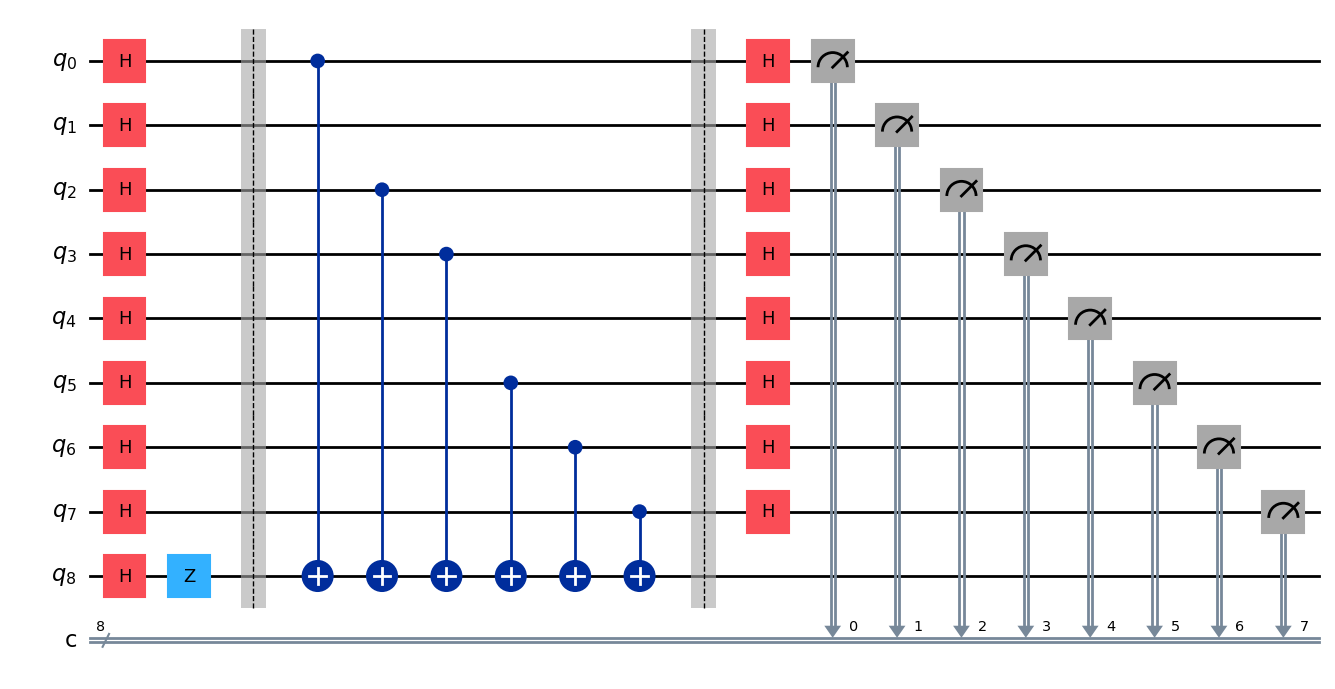

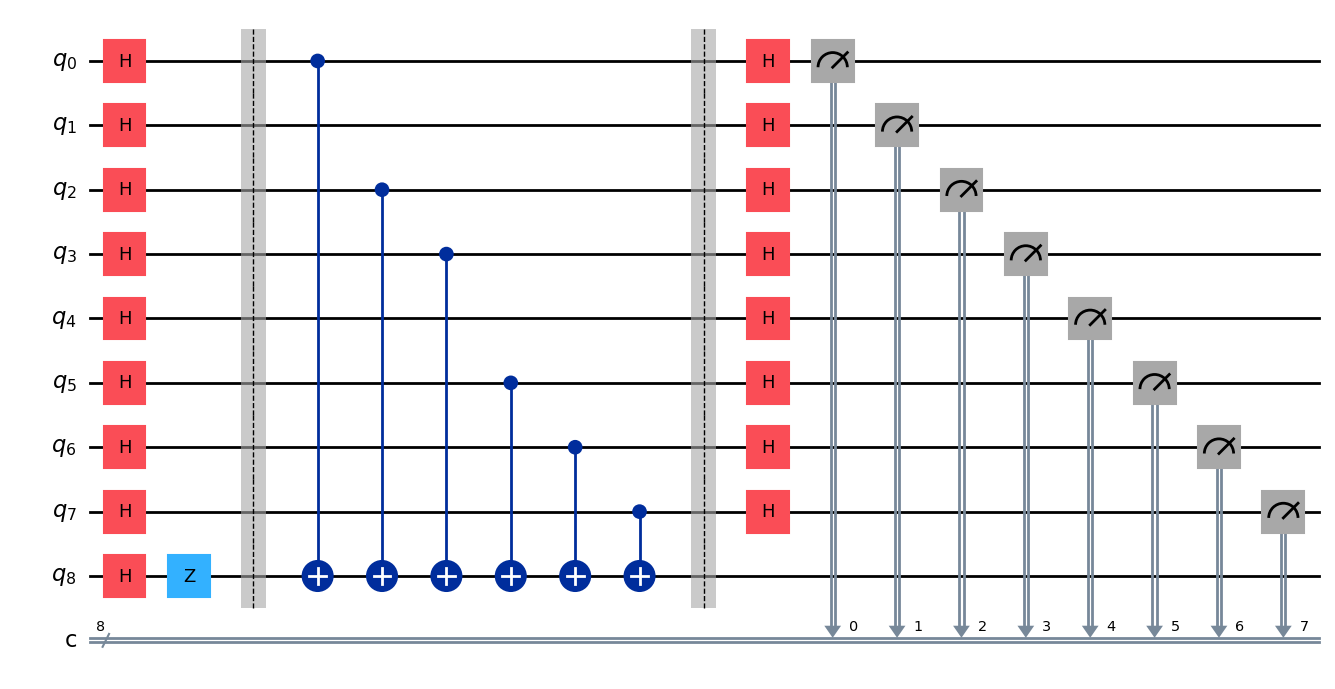

In [126]:
print("=" * 50)
print("Example 3: Secret string = '11101101'")
print("=" * 50)

secret = '11101101'
circuit = bernstein_vazirani_local(secret)

# Display circuit (might be large)
display(circuit.draw('mpl'))

Measurement results:
{'11101101': 1}

Secret string found: 11101101


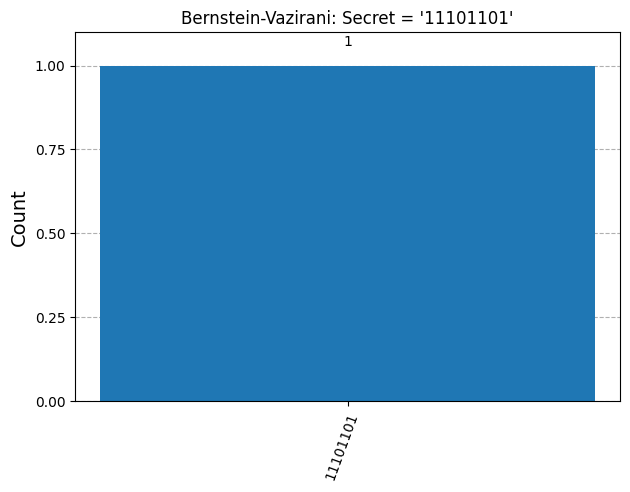

In [127]:
# Run on simulator
job = simulator.run(circuit, shots=1)
result = job.result()
counts = result.get_counts()

print(f"Measurement results:")
print(counts)
print(f"\nSecret string found: {max(counts, key=counts.get)}")

plot_histogram(counts)
plt.title(f"Bernstein-Vazirani: Secret = '{secret}'")
plt.show()

## Interactive Function: Try Your Own Secret Strings!

In [128]:
def find_secret_string(secret):
    """
    Simple wrapper to find any secret string
    """
    print(f"\n{'=' * 50}")
    print(f"Finding secret string: '{secret}'")
    print(f"{'=' * 50}")
    
    circuit = bernstein_vazirani_local(secret)
    
    simulator = AerSimulator()
    job = simulator.run(circuit, shots=1)
    result = job.result()
    counts = result.get_counts()
    
    found = max(counts, key=counts.get)
    confidence = counts[found] / 1 * 100
    
    print(f"\nSecret string found: {found}")
    print(f"Confidence: {confidence:.1f}%")
    
    # Show histogram
    plot_histogram(counts)
    plt.title(f"BV Algorithm: Secret = '{secret}'")
    plt.show()
    
    return found

Testing multiple secret strings:

Finding secret string: '101'

Secret string found: 101
Confidence: 100.0%


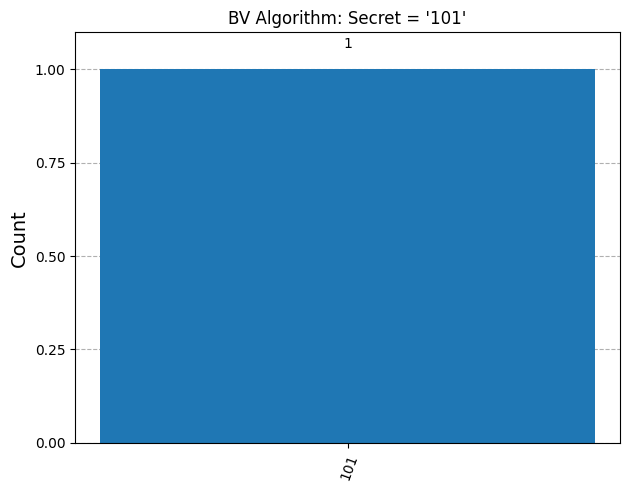


Finding secret string: '1111'

Secret string found: 1111
Confidence: 100.0%


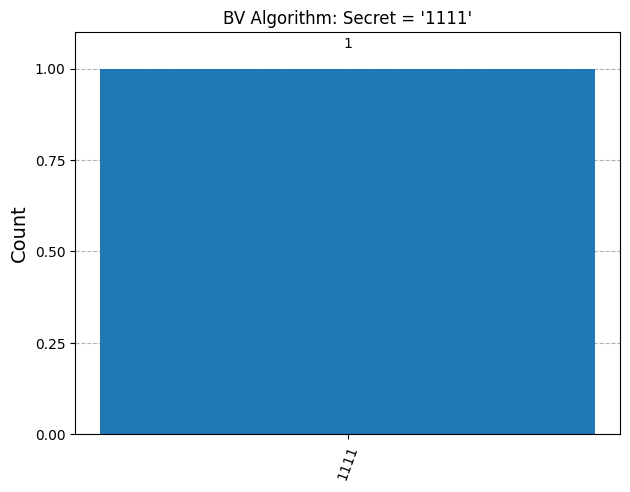


Finding secret string: '10101010'

Secret string found: 10101010
Confidence: 100.0%


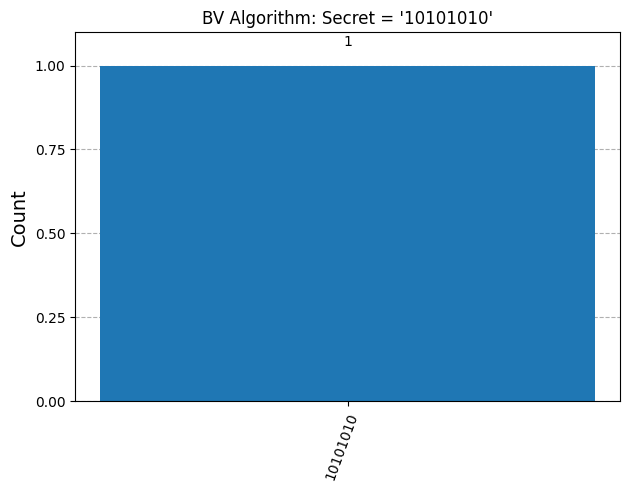


Finding secret string: '000'

Secret string found: 000
Confidence: 100.0%


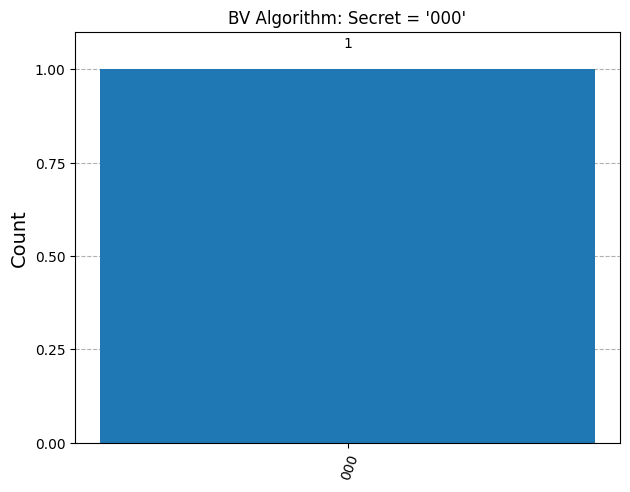

In [129]:
# Try multiple secret strings
print("Testing multiple secret strings:")
print("=" * 50)

test_strings = ['101', '1111', '10101010', '000']
for s in test_strings:
    find_secret_string(s)

## Try Your Own!

Change the secret string below to test any binary string you want:


Finding secret string: '10110'

Secret string found: 10110
Confidence: 100.0%


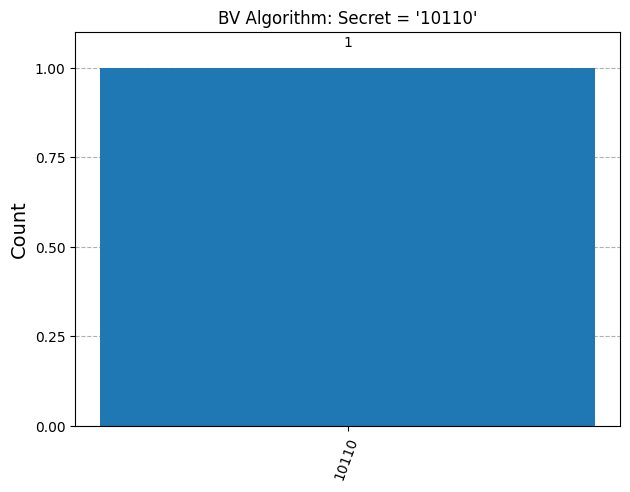

'10110'

In [130]:
# Enter your own secret string here!
my_secret = '10110'  # Change this to any binary string

find_secret_string(my_secret)

## Key Takeaways

- **Classical Algorithm**: Needs n queries to find an n-bit secret
- **Quantum Algorithm**: Needs only 1 query regardless of string length!
- **Why it works**: Quantum superposition + interference = exponential speedup
- **Perfect accuracy**: On ideal simulator, you get 100% correct answer
- **Real hardware**: Would have some noise/errors, but answer would still be most frequent result